# Day 1B — PyTorch, Step by Step

We use the same kind of fictional sensor data as Notebook 1. First we **inspect and
visualize it**, then translate the feature matrix into tensors and train one small network.

There is no large hyperparameter search. We change only the learning rate once, so the
training loop stays the main idea.

In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.7.1+cu126
Device: cuda


## 1. Generate and inspect the data

`X` is a matrix with samples in rows and features in columns. `y` contains one target per
row. Before creating tensors, we inspect the values, shapes, distributions, and relationships.

In [2]:
rng = np.random.default_rng(SEED)
n_samples = 600
feature_names = [
    "temperature", "humidity", "sensor_a", "sensor_b", "sensor_age"
]

temperature = rng.uniform(15, 45, n_samples)
humidity = rng.uniform(20, 85, n_samples)
sensor_a = rng.normal(0, 1, n_samples)
sensor_b = 0.65 * sensor_a + rng.normal(0, 0.65, n_samples)
sensor_age = rng.uniform(0, 1, n_samples)
X = np.column_stack([
    temperature, humidity, sensor_a, sensor_b, sensor_age
]).astype("float32")
noise = rng.normal(0, 1.8, n_samples)
y = (
    8 + 0.45 * temperature - 0.08 * humidity + 4 * sensor_a
    + 2.5 * sensor_b**2 - 5 * sensor_age + 2 * np.sin(sensor_a) + noise
).astype("float32")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600, 5)
y shape: (600,)


Feature order: ['temperature', 'humidity', 'sensor_a', 'sensor_b', 'sensor_age']

First five rows of X:
[[38.22 51.04 -0.99 -1.32  0.49]
 [28.17 69.49 -0.86 -0.65  0.11]
 [40.76 78.72  2.46  0.81  0.24]
 [35.92 66.85  1.8   1.72  0.53]
 [17.83 82.61 -0.41 -0.86  0.07]]

First five values of y:
[18.22 11.99 33.68 30.61  9.85]


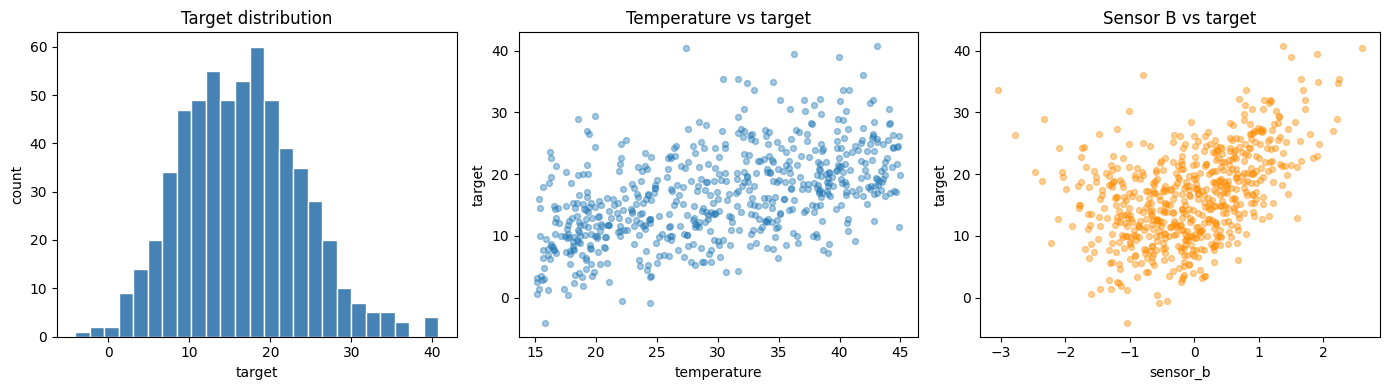

In [3]:
np.set_printoptions(precision=2, suppress=True)
print("Feature order:", feature_names)
print("\nFirst five rows of X:")
print(X[:5])
print("\nFirst five values of y:")
print(y[:5])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(y, bins=25, color="steelblue", edgecolor="white")
axes[0].set(title="Target distribution", xlabel="target", ylabel="count")
axes[1].scatter(temperature, y, alpha=0.4, s=18)
axes[1].set(title="Temperature vs target", xlabel="temperature", ylabel="target")
axes[2].scatter(sensor_b, y, alpha=0.4, s=18, color="darkorange")
axes[2].set(title="Sensor B vs target", xlabel="sensor_b", ylabel="target")
fig.tight_layout()

## 2. Split and scale with scikit-learn

PyTorch trains the network, while standard scikit-learn helpers keep splitting and scaling
easy to read. The scaler is fitted on training data only.

In [4]:
X_train, X_other, y_train, y_other = train_test_split(
    X, y, test_size=0.4, random_state=SEED
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_other, y_other, test_size=0.5, random_state=SEED
)

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train).astype("float32")
X_validation_scaled = feature_scaler.transform(X_validation).astype("float32")
X_test_scaled = feature_scaler.transform(X_test).astype("float32")

target_mean = y_train.mean()
target_std = y_train.std()
y_train_scaled = ((y_train - target_mean) / target_std).astype("float32")
y_validation_scaled = (
    (y_validation - target_mean) / target_std
).astype("float32")
print("Train / validation / test:", len(X_train), len(X_validation), len(X_test))

Train / validation / test: 360 120 120


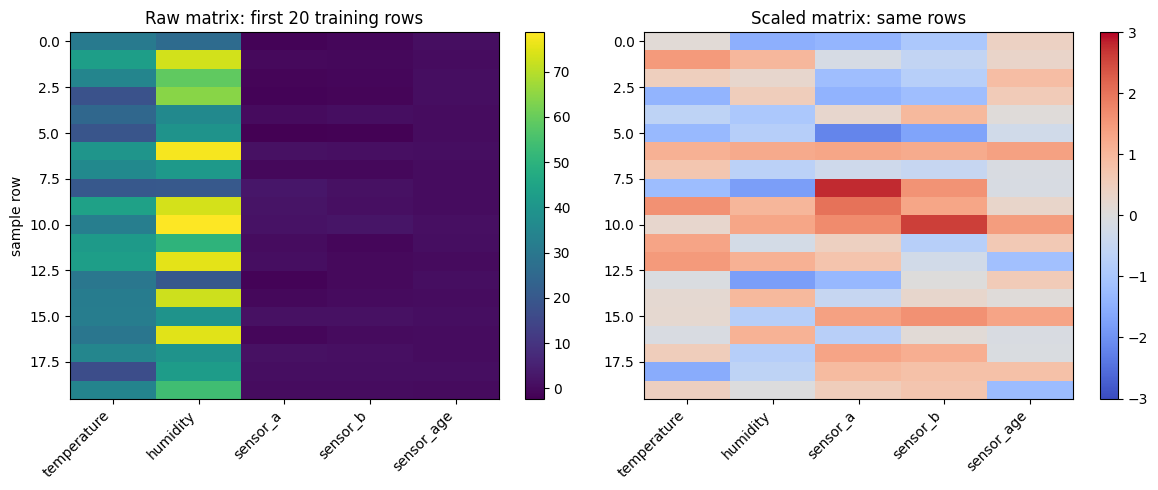

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
raw = axes[0].imshow(X_train[:20], aspect="auto", cmap="viridis")
axes[0].set_title("Raw matrix: first 20 training rows")
axes[0].set_xticks(range(5), feature_names, rotation=45, ha="right")
axes[0].set_ylabel("sample row")
fig.colorbar(raw, ax=axes[0])

scaled = axes[1].imshow(
    X_train_scaled[:20], aspect="auto", cmap="coolwarm", vmin=-3, vmax=3
)
axes[1].set_title("Scaled matrix: same rows")
axes[1].set_xticks(range(5), feature_names, rotation=45, ha="right")
fig.colorbar(scaled, ax=axes[1])
fig.tight_layout()

## 3. From arrays to tensors and mini-batches

A tensor is PyTorch's matrix object. `TensorDataset` keeps each feature row with its target.
`DataLoader` returns small batches and shuffles only the training data.

In [6]:
X_train_tensor = torch.from_numpy(X_train_scaled)
y_train_tensor = torch.from_numpy(y_train_scaled).reshape(-1, 1)
X_validation_tensor = torch.from_numpy(X_validation_scaled)
y_validation_tensor = torch.from_numpy(y_validation_scaled).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
validation_dataset = TensorDataset(
    X_validation_tensor, y_validation_tensor
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = DataLoader(
    validation_dataset, batch_size=128, shuffle=False
)

example_features, example_targets = next(iter(train_loader))
print("Feature batch shape:", example_features.shape)
print("Target batch shape:", example_targets.shape)
print("\nFirst three tensor rows:")
print(example_features[:3])

Feature batch shape: torch.Size([64, 5])
Target batch shape: torch.Size([64, 1])

First three tensor rows:
tensor([[ 1.0260, -1.2547, -0.5431, -0.1846, -1.3923],
        [-0.9426, -1.1966,  0.4190,  0.0987,  0.8651],
        [ 1.0273,  1.1386,  0.3708,  1.0245,  0.1318]])


## 4. A small neural network

The first linear layer multiplies a `(batch, 5)` matrix by learned weights. ReLU adds a
nonlinear step. The final layer produces one number per row.

In [7]:
class SmallRegressor(nn.Module):
    def __init__(self, hidden_width=16):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(5, hidden_width),
            nn.ReLU(),
            nn.Linear(hidden_width, 1),
        )

    def forward(self, features):
        return self.network(features)


model = SmallRegressor().to(device)
print(model)
for name, parameter in model.named_parameters():
    print(f"{name:20s} shape={tuple(parameter.shape)}")

SmallRegressor(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)
network.0.weight     shape=(16, 5)
network.0.bias       shape=(16,)
network.2.weight     shape=(1, 16)
network.2.bias       shape=(1,)


## 5. The training loop

Every batch follows five steps: clear gradients, predict, calculate loss, backpropagate,
and update weights. The helper records both curves and keeps the best validation weights.

In [8]:
def average_loss(model, data_loader, loss_function):
    model.eval()
    losses = []
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)
            prediction = model(features)
            losses.append(loss_function(prediction, targets).item())
    return np.mean(losses)


def train_model(learning_rate, epochs=80):
    torch.manual_seed(SEED)
    model = SmallRegressor().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()
    history = {"train": [], "validation": []}
    best_validation_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            prediction = model(features)
            loss = loss_function(prediction, targets)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        validation_loss = average_loss(
            model, validation_loader, loss_function
        )
        history["train"].append(train_loss)
        history["validation"].append(validation_loss)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history, best_validation_loss

## 6. One run and its learning curves

Both curves falling means the model is learning. A large and growing gap would warn about
overfitting.

Best standardized validation RMSE: 0.296


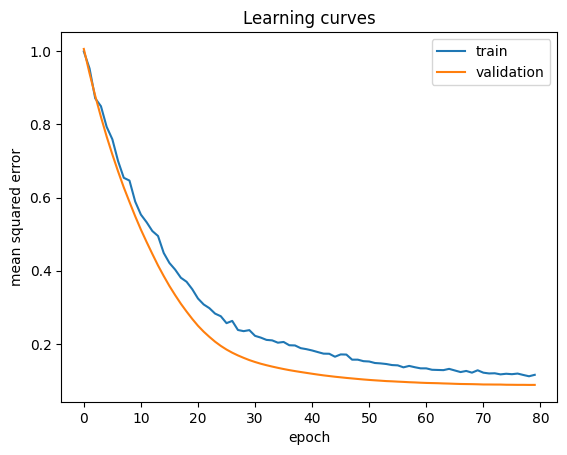

In [9]:
model, history, validation_loss = train_model(
    learning_rate=0.001, epochs=80
)
print(f"Best standardized validation RMSE: {validation_loss ** 0.5:.3f}")

plt.plot(history["train"], label="train")
plt.plot(history["validation"], label="validation")
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Learning curves")
plt.legend()
plt.show()

## 7. A very small hyperparameter experiment

The learning rate controls optimizer step size. We compare only **two** values and leave the
architecture unchanged. This is enough for a first experiment.

In [10]:
experiments = []
for learning_rate in [0.01, 0.001]:
    candidate, candidate_history, candidate_loss = train_model(
        learning_rate=learning_rate, epochs=80
    )
    experiments.append({
        "learning_rate": learning_rate,
        "model": candidate,
        "history": candidate_history,
        "validation_loss": candidate_loss,
    })
    print(
        f"learning rate={learning_rate}: "
        f"validation RMSE={candidate_loss ** 0.5:.3f}"
    )

best_experiment = min(
    experiments, key=lambda experiment: experiment["validation_loss"]
)
final_model = best_experiment["model"]
print("Selected learning rate:", best_experiment["learning_rate"])

learning rate=0.01: validation RMSE=0.227
learning rate=0.001: validation RMSE=0.296
Selected learning rate: 0.01


## 8. Look at the learned weight matrix

The first layer has 16 neurons and 5 inputs, so its weight matrix has shape `(16, 5)`.
The heatmap connects the mathematics to the stored parameters.

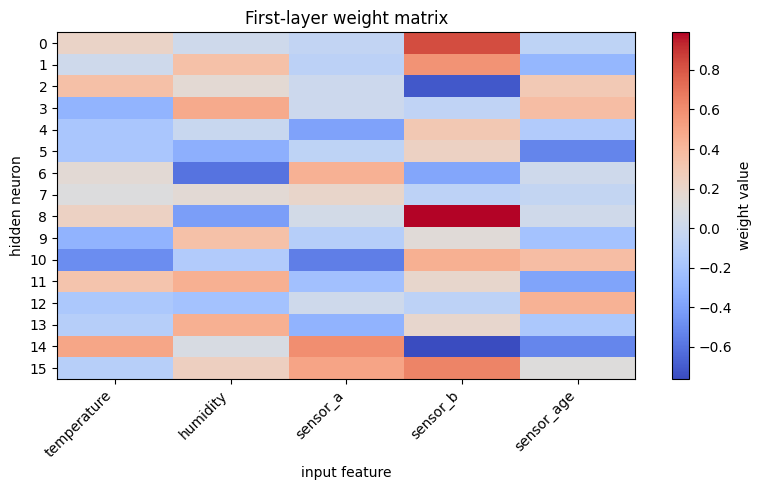

In [11]:
first_layer_weights = (
    final_model.network[0].weight.detach().cpu().numpy()
)
plt.figure(figsize=(8, 5))
plt.imshow(first_layer_weights, aspect="auto", cmap="coolwarm")
plt.colorbar(label="weight value")
plt.xticks(range(5), feature_names, rotation=45, ha="right")
plt.yticks(range(16))
plt.xlabel("input feature")
plt.ylabel("hidden neuron")
plt.title("First-layer weight matrix")
plt.tight_layout()

## 9. Final test evaluation

Use the selected model on the untouched test matrix. Predictions are transformed back to the
original target unit before calculating metrics.

Test MAE:  1.56
Test RMSE: 2.03
Test R²:   0.92


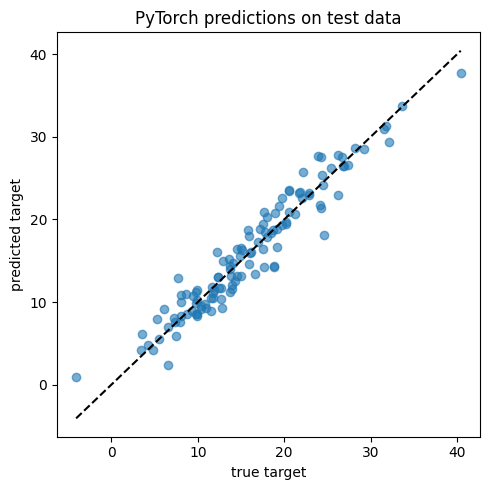

In [12]:
X_test_tensor = torch.from_numpy(X_test_scaled).to(device)
final_model.eval()
with torch.no_grad():
    scaled_prediction = final_model(X_test_tensor).cpu().numpy().ravel()
test_prediction = scaled_prediction * target_std + target_mean

print(f"Test MAE:  {mean_absolute_error(y_test, test_prediction):.2f}")
print(f"Test RMSE: {mean_squared_error(y_test, test_prediction) ** 0.5:.2f}")
print(f"Test R²:   {r2_score(y_test, test_prediction):.2f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, test_prediction, alpha=0.6)
limits = [
    min(y_test.min(), test_prediction.min()),
    max(y_test.max(), test_prediction.max()),
]
plt.plot(limits, limits, "k--")
plt.xlabel("true target")
plt.ylabel("predicted target")
plt.title("PyTorch predictions on test data")
plt.tight_layout()

## Takeaways

- Inspect arrays and plots before converting data to tensors.
- A tensor batch is still a matrix: rows are samples and columns are features.
- A small network and readable loop are enough to learn the PyTorch workflow.
- Change one hyperparameter at a time in a first experiment.
- Use `model.eval()` and `torch.no_grad()` for predictions.